In [1]:
pip install numpy pandas matplotlib plotly scikit-learn tensorflow yfinance streamlit joblib ta

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip list

Package                           Version
--------------------------------- --------------------
absl-py                           2.5.0
aiobotocore                       2.25.0
aiodns                            3.5.0
aiohappyeyeballs                  2.6.1
aiohttp                           3.13.2
aioitertools                      0.12.0
aiosignal                         1.4.0
alabaster                         0.7.16
altair                            5.5.0
anaconda-anon-usage               0.7.5
anaconda-auth                     0.12.3
anaconda-catalogs                 0.2.0
anaconda-cli-base                 0.7.0
anaconda-client                   1.14.0
anaconda-navigator                2.7.0
anaconda-project                  0.11.1
annotated-types                   0.6.0
anyio                             4.10.0
appdirs                           1.4.4
archspec                          0.2.5
argon2-cffi                       21.3.0
argon2-cffi-bindings              25.1.0
arrow        

In [3]:
import yfinance as yf
import pandas as pd
import os

In [69]:
companies = {
    "Reliance": "RELIANCE.NS",
    "TCS": "TCS.NS",
    "Infosys": "INFY.NS",
    "HDFC": "HDFCBANK.NS",
    "ICICI": "ICICIBANK.NS",
    "SBI": "SBIN.NS",
    "Wipro": "WIPRO.NS",
    "HCL": "HCLTECH.NS",
    "ITC": "ITC.NS",
    "AxisBank": "AXISBANK.NS",
    "Maruti": "MARUTI.NS",
    "AsianPaints": "ASIANPAINT.NS",
    "BajajFinance": "BAJFINANCE.NS",
    "LT": "LT.NS"
}

In [70]:
import yfinance as yf
import pandas as pd
import os

folder = "dataset"

companies = {
    "AsianPaints": "ASIANPAINT.NS",
    "TataMotors": "TATAMOTORS.NS"
}

for company, ticker in companies.items():

    print(f"\nDownloading {company}...")

    df = yf.download(
        ticker,
        start="2018-01-01",
        end="2026-01-01",
        auto_adjust=False,
        progress=False
    )

    if df.empty:
        print(f"❌ No data found for {company}")
        continue

    df = df.reset_index()

    # Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    # Keep only required columns
    df = df[["Date", "Open", "High", "Low", "Close", "Volume"]]

    # Save the CSV
    df.to_csv(os.path.join(folder, f"{company}.csv"), index=False)

    print(f"✅ {company}.csv saved successfully. Shape: {df.shape}")


1 Failed download:
['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')



✅ AsianPaints.csv saved successfully. Shape: (1976, 6)

❌ No data found for TataMotors


In [5]:
df = pd.read_csv("dataset/Reliance.csv")
print(df.head())

         Date        Open        High         Low       Close    Volume
0  2018-01-01  421.827393  421.827393  414.878479  415.907104   9453202
1  2018-01-02  417.392883  420.387329  414.375580  416.547119   9499419
2  2018-01-03  422.878876  423.336060  417.415741  418.215790  13507800
3  2018-01-04  419.747284  421.415955  418.627228  420.730194   9008932
4  2018-01-05  421.415955  423.747498  420.707336  422.078827   7441284


In [6]:
folder = "dataset"
os.makedirs(folder, exist_ok=True)

In [7]:
for i, col in enumerate(df.columns):
    print(i, col)

0 Date
1 Open
2 High
3 Low
4 Close
5 Volume


In [8]:
import os
import pandas as pd
import yfinance as yf

folder = "dataset"
os.makedirs(folder, exist_ok=True)

for company, ticker in companies.items():

    print(f"Downloading {company}...")

    df = yf.download(
        ticker,
        start="2018-01-01",
        auto_adjust=False,
        progress=False
    )

    # Convert index to a normal column
    df = df.reset_index()

    # Flatten MultiIndex columns
    df.columns = [
        col[0] if isinstance(col, tuple) else col
        for col in df.columns
    ]

    # Remove duplicate column names if any
    df = df.loc[:, ~df.columns.duplicated()]

    # Keep only the required columns
    df = df[["Date", "Open", "High", "Low", "Close", "Volume"]]

    # Save file
    df.to_csv(f"{folder}/{company}.csv", index=False)

print("✅ All datasets downloaded successfully!")


1 Failed download:
['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')



1 Failed download:
['ASIANPAINTS.NS']: YFTzMissingError('possibly delisted; no timezone found')


✅ All datasets downloaded successfully!


In [9]:
df = pd.read_csv("dataset/Reliance.csv")
print(df.head())
print(df.columns)

         Date        Open        High         Low       Close    Volume
0  2018-01-01  421.827393  421.827393  414.878479  415.907104   9453202
1  2018-01-02  417.392883  420.387329  414.375580  416.547119   9499419
2  2018-01-03  422.878876  423.336060  417.415741  418.215790  13507800
3  2018-01-04  419.747284  421.415955  418.627228  420.730194   9008932
4  2018-01-05  421.415955  423.747498  420.707336  422.078827   7441284
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [10]:
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [8]:
#processing
import pandas as pd
import os

In [16]:
import pandas as pd
import os

folder = "dataset"

files = [f for f in os.listdir(folder) if f.endswith(".csv")]

print(files)

for file in files:

    path = os.path.join(folder, file)

    df = pd.read_csv(path)

    # Convert Date column
    df["Date"] = pd.to_datetime(df["Date"])

    # Remove duplicates
    df.drop_duplicates(inplace=True)

    # Remove missing values
    df.dropna(inplace=True)

    # Sort by Date
    df.sort_values("Date", inplace=True)

    # Reset index
    df.reset_index(drop=True, inplace=True)

    # Save cleaned file
    df.to_csv(path, index=False)

print("✅ All datasets cleaned successfully.")

['AsianPaints.csv', 'AxisBank.csv', 'BajajFinance.csv', 'HCL.csv', 'HDFC.csv', 'ICICI.csv', 'Infosys.csv', 'ITC.csv', 'LT.csv', 'Maruti.csv', 'Reliance.csv', 'SBI.csv', 'TataMotors.csv', 'TCS.csv', 'Wipro.csv']
✅ All datasets cleaned successfully.


In [17]:
for file in files:

    path = os.path.join(folder, file)

    df = pd.read_csv(path)

    print(file)
    print(df.isnull().sum())
    print("-" * 40)

AsianPaints.csv
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
----------------------------------------
AxisBank.csv
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
----------------------------------------
BajajFinance.csv
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
----------------------------------------
HCL.csv
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
----------------------------------------
HDFC.csv
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
----------------------------------------
ICICI.csv
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
----------------------------------------
Infosys.csv
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
----------------------------------------
ITC.csv
Date      0
Open      0
H

In [18]:
for file in files:

    df = pd.read_csv(f"dataset/{file}")

    print(file, df.shape)

AsianPaints.csv (0, 6)
AxisBank.csv (2115, 6)
BajajFinance.csv (2115, 6)
HCL.csv (2115, 6)
HDFC.csv (2115, 6)
ICICI.csv (2115, 6)
Infosys.csv (2115, 6)
ITC.csv (2115, 6)
LT.csv (2115, 6)
Maruti.csv (2115, 6)
Reliance.csv (2115, 6)
SBI.csv (2115, 6)
TataMotors.csv (0, 6)
TCS.csv (2115, 6)
Wipro.csv (2115, 6)


In [19]:
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("dataset/Reliance.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,2018-01-01,421.827393,421.827393,414.878479,415.907104,9453202
1,2018-01-02,417.392883,420.387329,414.375580,416.547119,9499419
2,2018-01-03,422.878876,423.336060,417.415741,418.215790,13507800
3,2018-01-04,419.747284,421.415955,418.627228,420.730194,9008932
4,2018-01-05,421.415955,423.747498,420.707336,422.078827,7441284


In [21]:
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2115 entries, 0 to 2114
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2115 non-null   datetime64[ns]
 1   Open    2115 non-null   float64       
 2   High    2115 non-null   float64       
 3   Low     2115 non-null   float64       
 4   Close   2115 non-null   float64       
 5   Volume  2115 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 99.3 KB


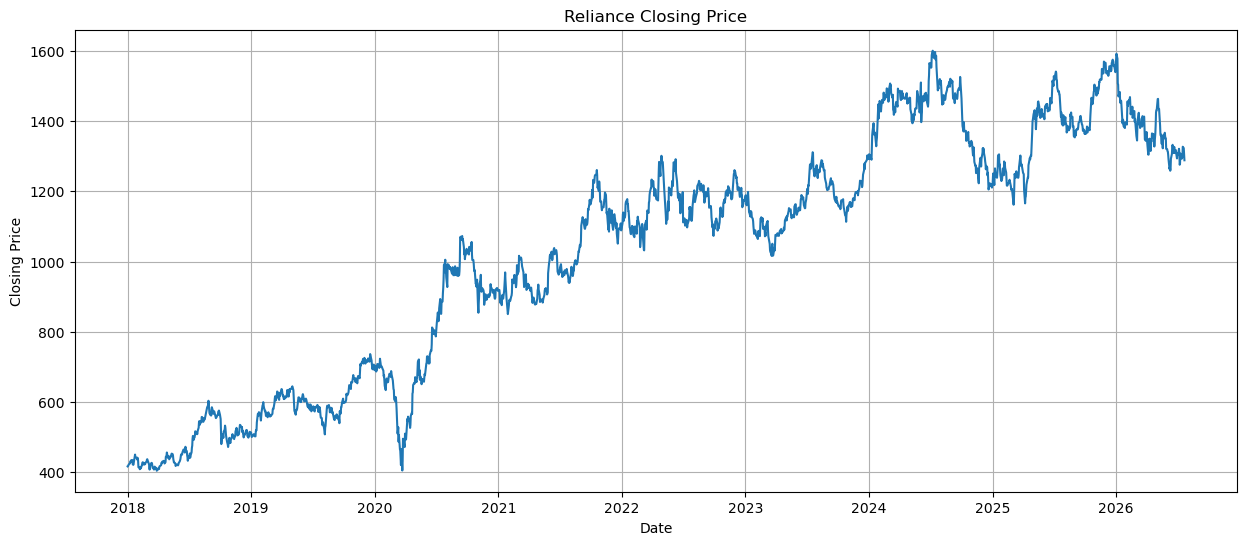

In [22]:
plt.figure(figsize=(15,6))
plt.plot(df["Date"], df["Close"])
plt.title("Reliance Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

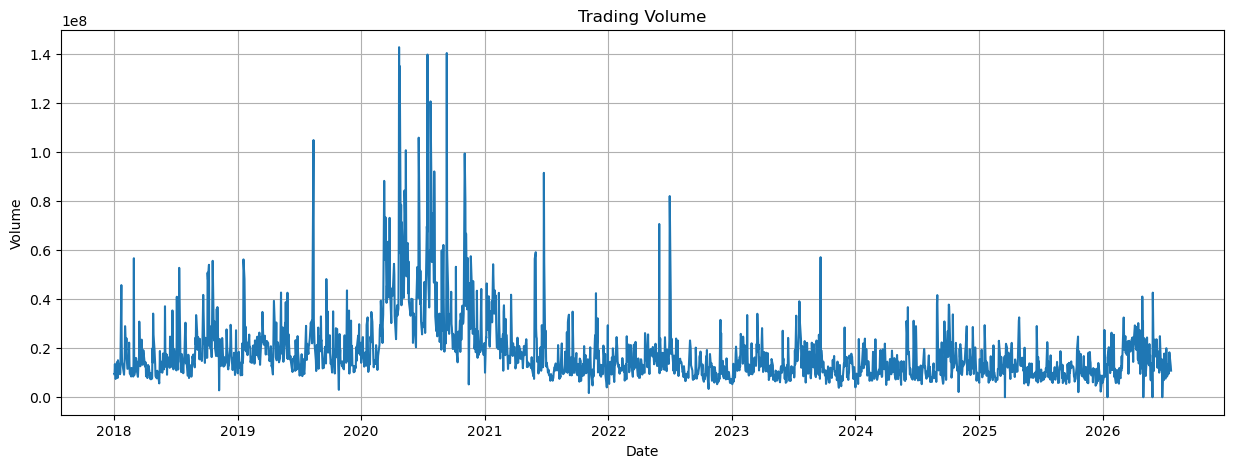

In [23]:
plt.figure(figsize=(15,5))

plt.plot(df["Date"], df["Volume"])

plt.title("Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.grid(True)

plt.show()

In [25]:
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()

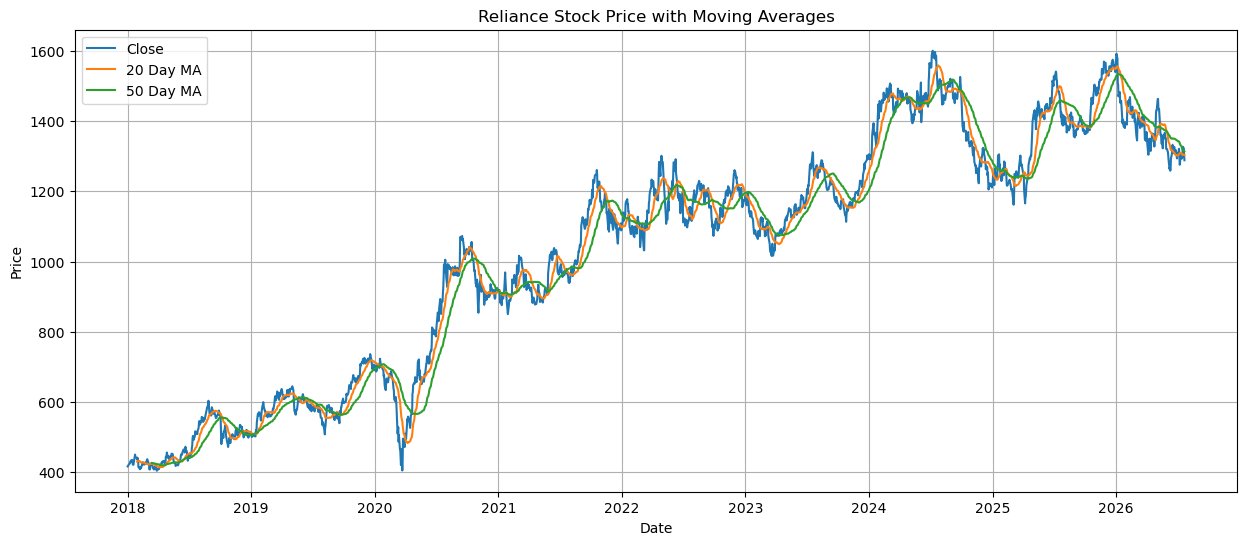

In [26]:
plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Close"], label="Close")

plt.plot(df["Date"], df["MA20"], label="20 Day MA")

plt.plot(df["Date"], df["MA50"], label="50 Day MA")

plt.title("Reliance Stock Price with Moving Averages")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

In [27]:
df["Daily_Return"] = df["Close"].pct_change()

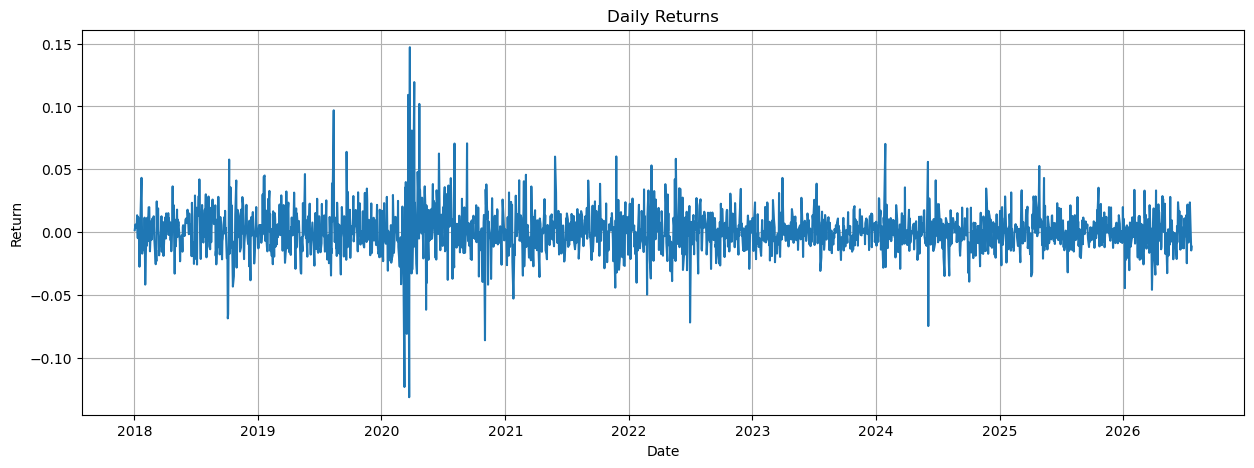

In [28]:
plt.figure(figsize=(15,5))

plt.plot(df["Date"], df["Daily_Return"])

plt.title("Daily Returns")

plt.xlabel("Date")

plt.ylabel("Return")

plt.grid(True)

plt.show()

In [29]:
df.to_csv("dataset/Reliance_EDA.csv", index=False)
print("EDA dataset saved successfully.")

EDA dataset saved successfully.


In [30]:
import pandas as pd
import numpy as np
from ta.momentum import RSIIndicator
from ta.trend import MACD

In [32]:
rsi = RSIIndicator(close=df["Close"], window=14)
df["RSI"] = rsi.rsi()

In [33]:
macd = MACD(close=df["Close"])
df["MACD"] = macd.macd()

In [34]:
df["Daily_Return"] = df["Close"].pct_change()

In [35]:
df["Volatility"] = df["Daily_Return"].rolling(20).std()

In [36]:
df["MA20"] = df["Close"].rolling(20).mean()
df["MA50"] = df["Close"].rolling(50).mean()

In [37]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [38]:
print(df.head())
print(df.columns)
print(df.shape)

        Date        Open        High         Low       Close    Volume  \
0 2018-03-14  424.616119  426.101898  420.227325  424.730408  14724464   
1 2018-03-15  422.878876  424.913269  416.021393  416.844269  12711836   
2 2018-03-16  415.564209  415.884247  405.072266  411.472595  30814962   
3 2018-03-19  411.906891  414.604156  407.792389  409.392487  12630833   
4 2018-03-20  408.386719  413.278381  405.529419  406.786621  15192983   

         MA20        MA50  Daily_Return        RSI      MACD  Volatility  
0  424.233235  425.188942     -0.003005  51.121647 -0.573120    0.013622  
1  423.733780  425.207685     -0.018567  45.157573 -1.005688    0.013508  
2  422.920024  425.106194     -0.012887  41.597679 -1.761644    0.013735  
3  422.330280  424.929728     -0.005055  40.273676 -2.499776    0.013391  
4  421.479950  424.650857     -0.006365  38.615495 -3.257472    0.013314  
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'MA20', 'MA50',
       'Daily_Return', 'RSI', 'M

In [39]:
df.to_csv("dataset/Reliance_Features.csv", index=False)
print("Feature Engineering Completed Successfully!")

Feature Engineering Completed Successfully!


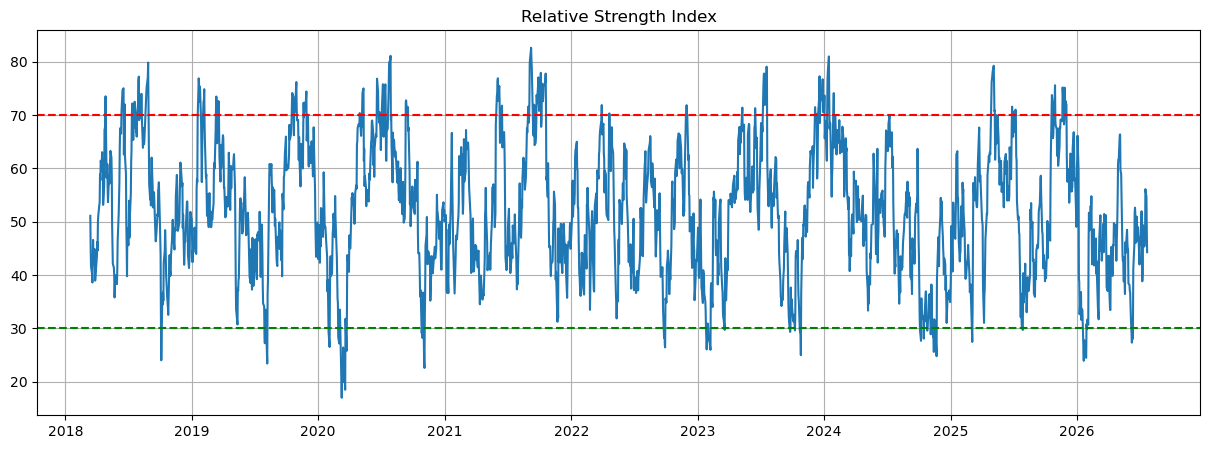

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df["Date"], df["RSI"])

plt.axhline(70, color="red", linestyle="--")

plt.axhline(30, color="green", linestyle="--")

plt.title("Relative Strength Index")

plt.grid(True)

plt.show()

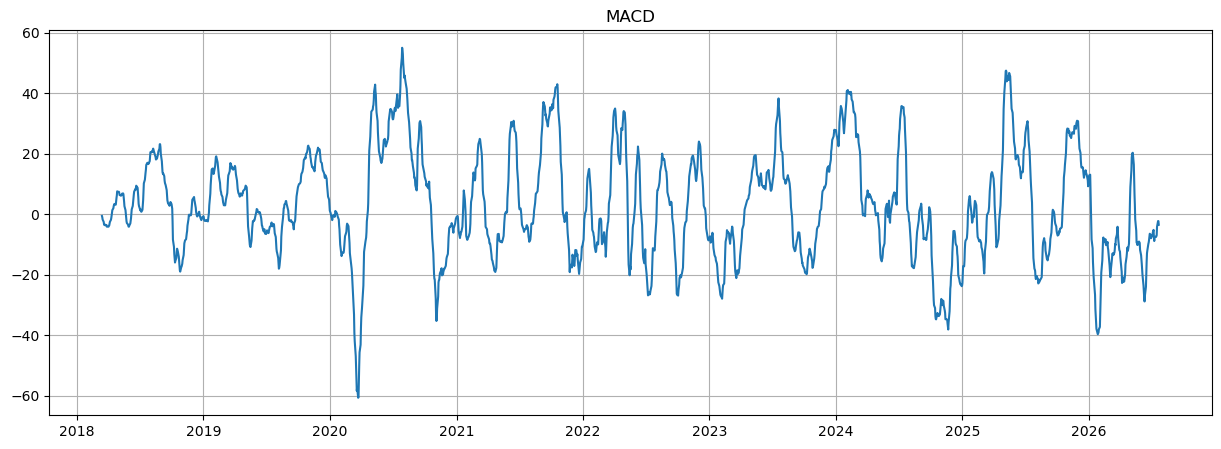

In [41]:
plt.figure(figsize=(15,5))

plt.plot(df["Date"], df["MACD"])

plt.title("MACD")

plt.grid(True)

plt.show()

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import os

In [44]:
data = df[["Close"]]
data.head()

,Close
0,424.730408
1,416.844269
2,411.472595
3,409.392487
4,406.786621


In [45]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)
scaled_data[:5]

array([[0.017697  ],
       [0.01111072],
       [0.00662446],
       [0.00488721],
       [0.00271087]])

In [46]:
os.makedirs("scalers", exist_ok=True)
joblib.dump(scaler, "scalers/Reliance_scaler.pkl")
print("Scaler Saved Successfully!")

Scaler Saved Successfully!


In [47]:
sequence_length = 60
X = []
y = []
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])
X = np.array(X)
y = np.array(y)
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (2006, 60, 1)
y Shape: (2006, 1)


In [48]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 1604
Testing Samples : 402


In [49]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(60,1)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(25))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

C:\Users\Vaibhavi\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,571 (201.45 KB)

 Trainable params: 51,571 (201.45 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - loss: 0.0336 - val_loss: 0.0013
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0036 - val_loss: 0.0016
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0026 - val_loss: 0.0012
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0024 - val_loss: 0.0011
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0024 - val_loss: 0.0015
Epoch 9/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 10/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0020 - val_loss: 9.8898e-04
Epoch 11/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0020 - val_loss: 0.0010
Epoch 12/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss

In [51]:
os.makedirs("models", exist_ok=True)

model.save("models/Reliance.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [52]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_actual = scaler.inverse_transform(y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


In [53]:
rmse = np.sqrt(mean_squared_error(y_actual, predictions))
mae = mean_absolute_error(y_actual, predictions)

print("RMSE :", rmse)
print("MAE :", mae)

RMSE : 34.2969534875642
MAE : 26.786428878556436


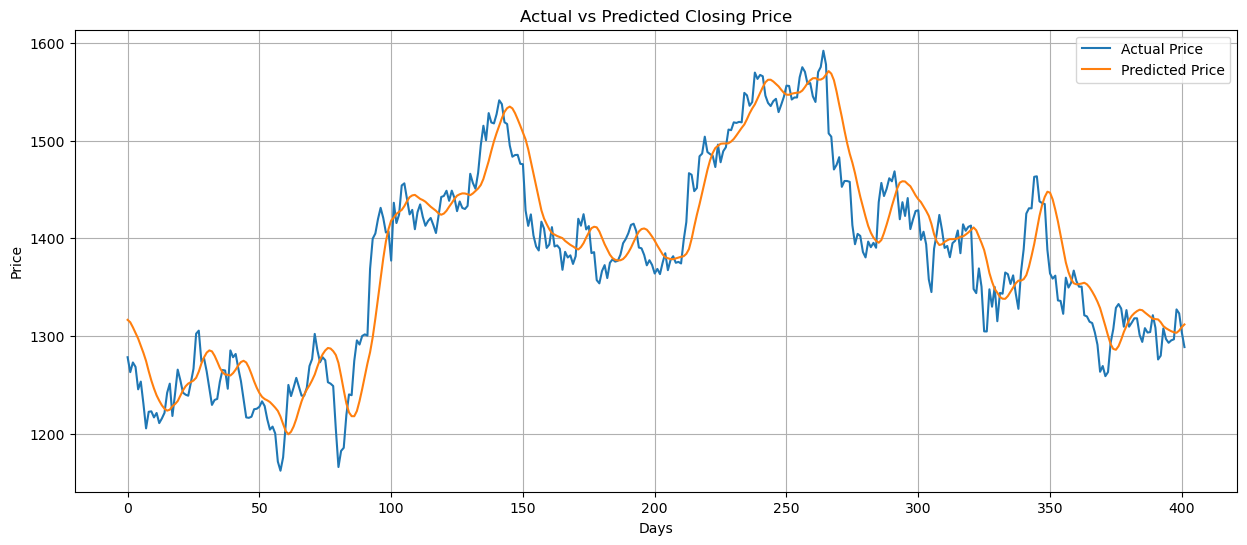

In [54]:
plt.figure(figsize=(15,6))

plt.plot(y_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#all data 

In [55]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [56]:
os.makedirs("models", exist_ok=True)
os.makedirs("scalers", exist_ok=True)

In [57]:
folder = "dataset"
feature_files = [f for f in os.listdir(folder) if f.endswith("_Features.csv")]
print(feature_files)

['Reliance_Features.csv']


In [58]:
import pandas as pd

df = pd.read_csv("dataset/AsianPaints.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (0, 6)
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Volume]
Index: []


In [60]:
companies = {
    "Reliance": "RELIANCE.NS",
    "TCS": "TCS.NS",
    "Infosys": "INFY.NS",
}